# 02 — EDA: проверка гипотез

Краткая памятка по углублённому EDA. Подробные правила и готовые шаблоны скрыты, чтобы не занимать место во время работы.

<details>
<summary><strong>Развернуть / свернуть памятку и базовые шаблоны</strong></summary>

Этот notebook предназначен для **проектно-специфичных исследований**, которые не входят в автоматический технический профиль [[notebooks/02_eda.ipynb]]. Здесь проверяются связи target с отдельными признаками, взаимодействия признаков, корреляции и возможные направления feature engineering.

## Принцип исследования

Для каждого вопроса сохраняйте цепочку:

```text
Вопрос → метод → наблюдение → интерпретация → гипотеза → следующее действие
```

График без текстового вывода не считается завершённым исследованием. Корреляция показывает связь, но не доказывает причинность.

## Базовые шаблоны

### Target и категориальный признак

Для бинарного target `0/1` или числового regression-target текстовый отчёт содержит размер группы, средний target и границы bootstrap CI:

```python
FEATURE = categorical_features[0]
report = grouped_target_report(
    train,
    feature=FEATURE,
    target=TARGET,
    ci_level=CI_LEVEL,
    n_boot=CI_BOOTSTRAPS,
    seed=CI_SEED,
)
display(report)
sns.barplot(
    data=train,
    x=FEATURE,
    y=TARGET,
    errorbar=("ci", CI_LEVEL),
    n_boot=CI_BOOTSTRAPS,
    seed=CI_SEED,
    capsize=0.15,
)
```

Для бинарного target столбцы `target_rate`, `ci_low` и `ci_high` форматируются как проценты. Для строкового или multiclass-target используйте таблицу долей классов:

```python
pd.crosstab(train[FEATURE], train[TARGET], normalize="index")
```

CI отражает неопределённость среднего target, а не разброс отдельных наблюдений. Проверяйте также `rows`: сильный эффект в маленькой группе может быть нестабилен.
### Target и числовой признак

```python
FEATURE = "feature_name"
display(train.groupby(TARGET)[FEATURE].describe())
sns.boxplot(data=train, x=TARGET, y=FEATURE)
sns.histplot(data=train, x=FEATURE, hue=TARGET, stat="density", common_norm=False)
```

Смотрите форму распределения, выбросы, пропуски и возможную нелинейность. Средних значений недостаточно.

### Target и дискретный признак

Дискретный признак выбирается только из явно настроенной группы `count`:

```python
FEATURE = discrete_features[0]
report = grouped_target_report(
    train,
    feature=FEATURE,
    target=TARGET,
    ci_level=CI_LEVEL,
    n_boot=CI_BOOTSTRAPS,
    seed=CI_SEED,
)
report.insert(1, "share", report["rows"] / len(train))
display(report)
```

Для дискретного признака проверяйте отдельные уровни, `rows`, долю выборки, CI, редкие значения, монотонность и возможные пороги. Не применяйте сглаживание как единственный способ анализа: между соседними целыми значениями может не существовать наблюдений.
### Первичный обзор текстового признака

Минимальная диагностика выполняется для первого явно настроенного `text`-признака:

```python
TEXT_FEATURE = text_features[0]
display(train[[TEXT_FEATURE]].head(20))
display(train[[TEXT_FEATURE]].sample(20, random_state=42))
```

Далее проверяются только `NaN`, пустые строки, специальные символы, уникальность и top-20 точных повторений. После этих трёх блоков вручную определяется тип поля: категория, идентификатор, структурированная строка, свободный текст или пока непонятно. Более глубокий NLP-анализ в базовый шаблон не входит.
### Корреляции

```python
columns = [*numeric_features, TARGET]
correlation = train[columns].corr(method="spearman")
display(correlation)
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0)
```

- `pearson` — линейная связь;
- `spearman` — монотонная связь и меньшая чувствительность к выбросам;
- высокая корреляция между признаками может указывать на дублирование или multicollinearity;
- низкая корреляция с target не означает бесполезность нелинейного признака.

### Линейная зависимость двух числовых признаков

```python
sns.scatterplot(data=train, x="feature_x", y="feature_y", hue=TARGET)
sns.regplot(data=train, x="feature_x", y="feature_y", scatter=False)
```

Линия тренда — диагностический инструмент, а не доказательство, что линейная модель будет оптимальна.

### Взаимодействие двух категориальных признаков

```python
interaction = pd.pivot_table(
    train,
    values=TARGET,
    index="feature_a",
    columns="feature_b",
    aggfunc="mean",
)
display(interaction)
sns.heatmap(interaction, annot=True, cmap="viridis")
```

Взаимодействие полезно, когда эффект одного признака меняется внутри значений другого.

## Правила безопасности

- Не изменяйте файлы в `data/raw/`; работайте с `train.copy()`.
- Не используйте test target: его нет и он не должен появляться.
- Временные исследовательские колонки допустимы только внутри notebook.
- Принятую новую feature переносите в будущий `src/ml_project/features.py` и проверяйте отдельным экспериментом.
- Главные выводы переносите в [[docs/02_eda.md]], а идеи — в [[hypotheses/_index.md]].

</details>

In [5]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.profiling as profiling
import ml_project.eda_findings as eda_findings
import ml_project.config as project_config

# Перечитываем изменяемые модули без restart kernel.
profiling = importlib.reload(profiling)
eda_findings = importlib.reload(eda_findings)
grouped_target_report = profiling.grouped_target_report
validate_feature_groups = profiling.validate_feature_groups
save_eda_finding = eda_findings.save_eda_finding

project_config = importlib.reload(project_config)
DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET

catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()
train = catalog.load(TRAIN_DATASET).copy()

if TARGET is None or TARGET not in train.columns:
    raise ValueError("Настройте TARGET в src/ml_project/config.py перед исследованием.")

feature_groups = validate_feature_groups(
    train,
    FEATURE_GROUPS,
    target=TARGET,
)
continuous_features = list(feature_groups["numeric"])
discrete_features = list(feature_groups["count"])
text_features = list(feature_groups["text"])
numeric_features = [*continuous_features, *discrete_features]
categorical_features = [
    *feature_groups["categorical"],
    *feature_groups["ordinal"],
]

FIGURE_DIR = PROJECT_ROOT / "assets" / "eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")


print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Train: {train.shape[0]} строк × {train.shape[1]} столбцов")
print(f"Target: {TARGET}")
print("Непрерывные числовые:", ", ".join(continuous_features) or "—")
print("Дискретные / счётные:", ", ".join(discrete_features) or "—")
print("Текстовые:", ", ".join(text_features) or "—")
print("Категориальные + порядковые:", ", ".join(categorical_features) or "—")

Корень проекта: D:\Projects\Titanik-ML-project
Train: 891 строк × 12 столбцов
Target: Survived
Непрерывные числовые: Age, Fare
Дискретные / счётные: SibSp, Parch
Текстовые: Name
Категориальные + порядковые: Sex, Cabin, Embarked, Pclass


## Параметры исследования

Эти настройки управляют визуализациями и объёмом диагностических отчётов. Обычно значения по умолчанию менять не требуется.

| Параметр | Назначение | Когда изменять |
|---|---|---|
| `CI_LEVEL` | Уровень доверительного интервала на графиках и в таблицах | Обычно оставлять `95`; менять только при осознанном статистическом требовании |
| `CI_BOOTSTRAPS` | Количество bootstrap-перевыборок для расчёта CI | Увеличить для более стабильной оценки; уменьшить, если расчёт слишком медленный |
| `CI_SEED` | Делает bootstrap-оценки воспроизводимыми | Обычно не менять внутри одного проекта |
| `MAX_DISCRETE_LEVELS` | Максимальное количество уровней дискретного признака на графике | Увеличить, если график остаётся читаемым; полная таблица всё равно содержит все уровни |
| `TEXT_SAMPLE_SIZE` | Количество первых, случайных и проблемных текстовых строк для просмотра | Изменить, если 20 примеров недостаточно или слишком много |
| `TEXT_TOP_VALUES` | Количество частых текстовых значений и специальных символов в отчёте | Увеличить для более детального обзора повторений |
| `TEXT_PREVIEW_CHARS` | Максимальная длина текстового значения только при отображении top-значений | Увеличить для длинных текстов; исходные данные не обрезаются |
| `TEXT_SAMPLE_SEED` | Фиксирует случайную выборку текстовых строк | Изменить, если нужна другая воспроизводимая выборка |
| `TEXT_SPECIAL_PATTERN` | Регулярное выражение для поиска символов вне букв, цифр и пробелов; `_` тоже считается специальным | Изменять только под особенности конкретного формата текста |
| `LAST_FIGURE` | Служебная ссылка на последний построенный Matplotlib-график для сохранения в Obsidian | Вручную не изменять |

> [!note]
> Изменение параметров влияет только на исследовательский вывод notebook. Raw-данные не изменяются.

In [7]:
# --- Доверительные интервалы ---
CI_LEVEL = 95          # уровень CI в процентах
CI_BOOTSTRAPS = 1000   # количество bootstrap-перевыборок
CI_SEED = 42           # воспроизводимость bootstrap

# --- Дискретные признаки ---
MAX_DISCRETE_LEVELS = 30  # максимум уровней на графике; таблица не обрезается

# --- Текстовые признаки ---
TEXT_SAMPLE_SIZE = 20     # размер первых, случайных и проблемных выборок
TEXT_TOP_VALUES = 20      # количество частых значений / специальных символов
TEXT_PREVIEW_CHARS = 120  # длина preview; исходный текст не изменяется
TEXT_SAMPLE_SEED = 42     # воспроизводимость случайной выборки
TEXT_SPECIAL_PATTERN = r"[^\w\s]|_"  # пунктуация и `_`

# --- Служебное состояние ---
# Аналитические ячейки сами обновляют эту ссылку после построения графика.
LAST_FIGURE = None

## План исследования

Перед запуском графиков сформулируйте вопросы. Удаляйте нерелевантные пункты и добавляйте свои.

- [ ] Как каждый ключевой категориальный признак связан с target?
- [ ] Как распределения числовых признаков отличаются между классами target?
- [ ] Как дискретные/count-признаки связаны с target и есть ли редкие уровни?
- [ ] Что представляют собой текстовые признаки: категории, идентификаторы, структурированные строки или свободный текст?
- [ ] Есть ли сильные Pearson/Spearman-корреляции?
- [ ] Есть ли признаки, дублирующие друг друга?
- [ ] Есть ли важные взаимодействия двух признаков?
- [ ] Какие наблюдения превращаются в проверяемые feature-гипотезы?

## 1. Target × категориальный признак

Измените `CATEGORICAL_FEATURE`. Для Titanic первым примером автоматически станет `Sex`, если столбец существует.

На графике показывается 95% bootstrap CI для среднего target. Интервал отражает неопределённость оценки, а не разброс отдельных наблюдений.

In [86]:
train["Deck"] = (
    train["Cabin"]
    .astype("string")
    .str.extract(r"^\s*([A-Za-z])", expand=False)
    .str.upper()
    .fillna("<NA>")
)
display(train["Deck"].head(5))

0    <NA>
1       C
2    <NA>
3       C
4    <NA>
Name: Deck, dtype: string

,rows,target_rate,ci_low,ci_high
Deck,,,,
D,33,75.76%,60.61%,87.88%
E,32,75.00%,59.38%,87.58%
B,47,74.47%,61.70%,85.11%
F,13,61.54%,30.77%,84.62%
C,59,59.32%,47.46%,72.88%
G,4,50.00%,0.00%,100.00%
A,15,46.67%,20.00%,73.33%
,687,29.99%,26.35%,33.19%
T,1,0.00%,0.00%,0.00%


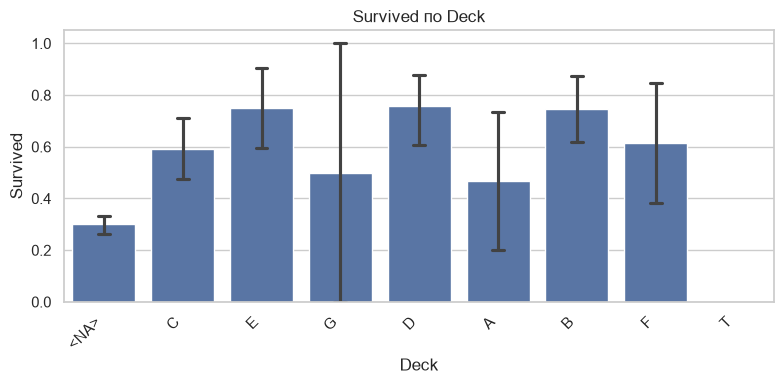

In [87]:
LAST_FIGURE = None
CATEGORICAL_FEATURE = "Deck" if categorical_features else None

if CATEGORICAL_FEATURE is None:
    print("В FEATURE_GROUPS нет categorical/ordinal признаков.")
elif pd.api.types.is_numeric_dtype(train[TARGET]):
    categorical_target_report = grouped_target_report(
        train,
        feature=CATEGORICAL_FEATURE,
        target=TARGET,
        ci_level=CI_LEVEL,
        n_boot=CI_BOOTSTRAPS,
        seed=CI_SEED,
    )
    estimate_column = (
        "target_rate"
        if "target_rate" in categorical_target_report.columns
        else "target_mean"
    )
    categorical_target_report = categorical_target_report.sort_values(
        estimate_column,
        ascending=False,
    )
    if estimate_column == "target_rate":
        report_formats = {
            "target_rate": "{:.2%}",
            "ci_low": "{:.2%}",
            "ci_high": "{:.2%}",
        }
    else:
        report_formats = {
            "target_mean": "{:.3f}",
            "ci_low": "{:.3f}",
            "ci_high": "{:.3f}",
        }
    display(categorical_target_report.style.format(report_formats))

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=train,
        x=CATEGORICAL_FEATURE,
        y=TARGET,
        errorbar=("ci", CI_LEVEL),
        n_boot=CI_BOOTSTRAPS,
        seed=CI_SEED,
        capsize=0.15,
    )
    plt.title(f"{TARGET} по {CATEGORICAL_FEATURE}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    LAST_FIGURE = plt.gcf()
    plt.show()
else:
    categorical_target_report = pd.crosstab(
        train[CATEGORICAL_FEATURE],
        train[TARGET],
        normalize="index",
        dropna=False,
    )
    display(categorical_target_report)

    plt.figure(figsize=(9, 4))
    sns.countplot(
        data=train,
        x=CATEGORICAL_FEATURE,
        hue=TARGET,
    )
    plt.title(f"Распределение {TARGET} по {CATEGORICAL_FEATURE}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    LAST_FIGURE = plt.gcf()
    plt.show()

### Вывод по категориальному признаку

- **Вопрос:**Как влияет пол на выживаемость?
- **Наблюдение:** Это прям очень важная фича, можно будет дать ей сразу увеличенный вес
- **Надёжность:** достаточно ли строк в каждой группе? достаточно
- **Возможное объяснение:**
- **Feature-гипотеза:**
- **Следующий шаг:**

## 2. Target × числовой признак

Измените `NUMERIC_FEATURE`. Для Titanic первым примером автоматически станет `Age`, если столбец существует.

Третья панель показывает среднее и 95% bootstrap CI по классам. Для непрерывного regression-target вместо групп используется линия регрессии с 95% CI.

In [71]:
fare_frame = train.assign(
    LogFare=np.log1p(train["Fare"])
)
fare_frame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3.196630
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,3.433987


In [42]:

    # result["FarpPer"]=result["Fare"]/TicketGroupSize
fare_frame = train.assign(TicketGroupSize=train.groupby("Ticket")["Ticket"]
    .transform("size"))


# Выводим результат
display(IsnotAlone)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketGroupSize
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S,2
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN,2
72,73,0,2,"Hood, Mr. Ambrose Jr",male,21.0,0,0,S.O.C. 14879,73.5000,NaN,S,5
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S,7
79,80,1,3,"Dowdell, Miss. Elizabeth",female,30.0,0,0,364516,12.4750,NaN,S,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0000,B28,NaN,2
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S,7
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,NaN,S,2
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C,2


,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,2.404337,0.683626,0.0,2.166192,2.202765,2.639057,5.406181
1,342.0,2.913755,0.782958,0.0,2.191654,2.639057,3.433987,5.146194


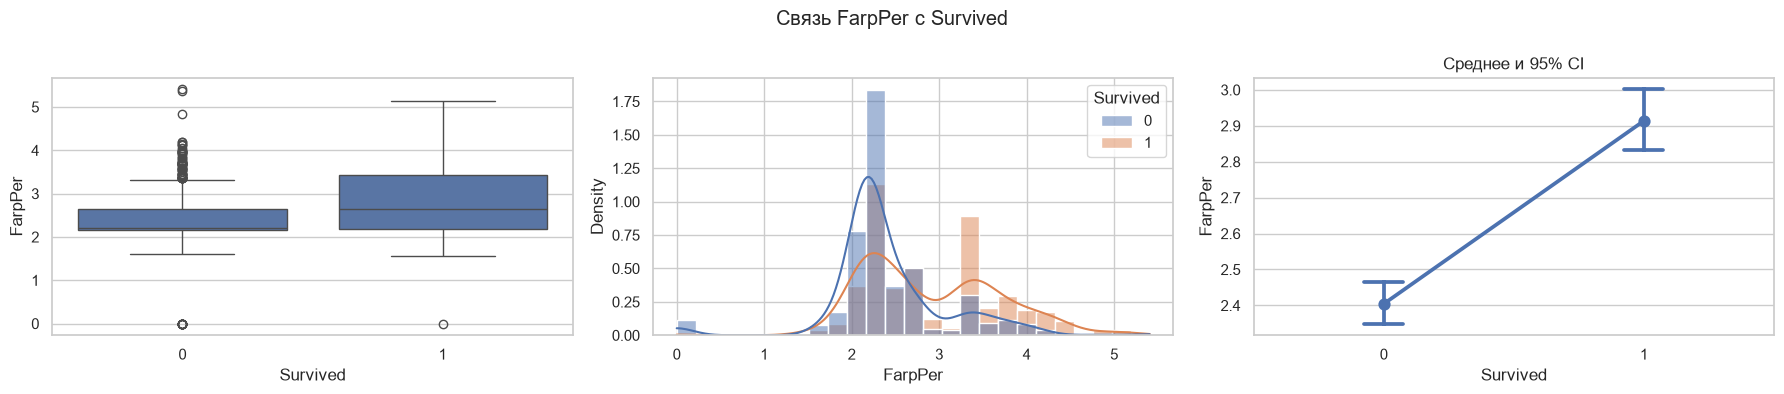

In [38]:
LAST_FIGURE = None
NUMERIC_FEATURE = "FarpPer" if continuous_features else None

if NUMERIC_FEATURE is None:
    print("В FEATURE_GROUPS нет numeric-признаков.")
else:
    display(fare_frame.groupby(TARGET)[NUMERIC_FEATURE].describe())

    figure, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.boxplot(
        data=fare_frame,
        x=TARGET,
        y=NUMERIC_FEATURE,
        ax=axes[0],
    )
    sns.histplot(
        data=fare_frame,
        x=NUMERIC_FEATURE,
        hue=TARGET,
        stat="density",
        common_norm=False,
        kde=True,
        ax=axes[1],
    )
    target_cardinality = train[TARGET].nunique(dropna=True)
    if target_cardinality <= 20:
        sns.pointplot(
            data=fare_frame,
            x=TARGET,
            y=NUMERIC_FEATURE,
            estimator="mean",
            errorbar=("ci", CI_LEVEL),
            n_boot=CI_BOOTSTRAPS,
            seed=CI_SEED,
            capsize=0.15,
            ax=axes[2],
        )
        axes[2].set_title(f"Среднее и {CI_LEVEL}% CI")
    elif pd.api.types.is_numeric_dtype(train[TARGET]):
        sns.regplot(
            data=fare_frame,
            x=NUMERIC_FEATURE,
            y=TARGET,
            ci=CI_LEVEL,
            n_boot=CI_BOOTSTRAPS,
            seed=CI_SEED,
            scatter_kws={"alpha": 0.35},
            ax=axes[2],
        )
        axes[2].set_title(f"Регрессия и {CI_LEVEL}% CI")
    else:
        axes[2].axis("off")
        axes[2].text(
            0.5,
            0.5,
            "Слишком много классов\nдля читаемого CI-графика",
            ha="center",
            va="center",
        )
    figure.suptitle(f"Связь {NUMERIC_FEATURE} с {TARGET}")
    figure.tight_layout()
    LAST_FIGURE = figure
    plt.show()

In [37]:
train.loc[
    train["Parch"]>2
]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
86,87,0,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.3750,NaN,S
167,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,NaN,S
360,361,0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S
437,438,1,2,"Richards, Mrs. Sidney (Emily Hocking)",female,24.0,2,3,29106,18.7500,NaN,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
567,568,0,3,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,349909,21.0750,NaN,S
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.2750,NaN,S
638,639,0,3,"Panula, Mrs. Juha (Maria Emilia Ojala)",female,41.0,0,5,3101295,39.6875,NaN,S


### Вывод по числовому признаку

- **Вопрос:**
- **Наблюдение:**
- **Есть ли выбросы / пропуски / нелинейность:**
- **Возможное объяснение:**
- **Нужна ли трансформация или binning:**
- **Следующий шаг:**

## 3. Target × дискретный признак

Дискретные числовые признаки хранят числа, но принимают отдельные счётные значения. Поэтому их полезно анализировать и как числа, и как уровни, а не только через непрерывную гистограмму или корреляцию.

По умолчанию выбирается первый признак из группы `count`. При необходимости явно замените `DISCRETE_FEATURE`. Таблица покажет частоту каждого значения, долю выборки, target-статистику и bootstrap CI.

In [45]:
fare_frame["IsnotAlone"] = (
    (fare_frame["TicketGroupSize"] > 1) &
    (fare_frame["Parch"] == 0) &
    (fare_frame["SibSp"] == 0)
).astype(int)
fare_frame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TicketGroupSize,IsnotAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,2,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,0


In [83]:
display(
    fare_frame[
        ["PassengerId", "SibSp", "Parch", "Relatives", TARGET]
    ].head(20)
)

,PassengerId,Cabin,Deck,Survived
0,1,NaN,<NA>,0
1,2,C85,C,1
2,3,NaN,<NA>,1
3,4,C123,C,1
4,5,NaN,<NA>,0
5,6,NaN,<NA>,0
6,7,E46,E,0
7,8,NaN,<NA>,0
8,9,NaN,<NA>,1
9,10,NaN,<NA>,1


,rows,share,target_rate,ci_low,ci_high
IsnotAlone,,,,,
0,816,91.58%,37.25%,34.07%,40.69%
1,75,8.42%,50.67%,40.00%,61.33%


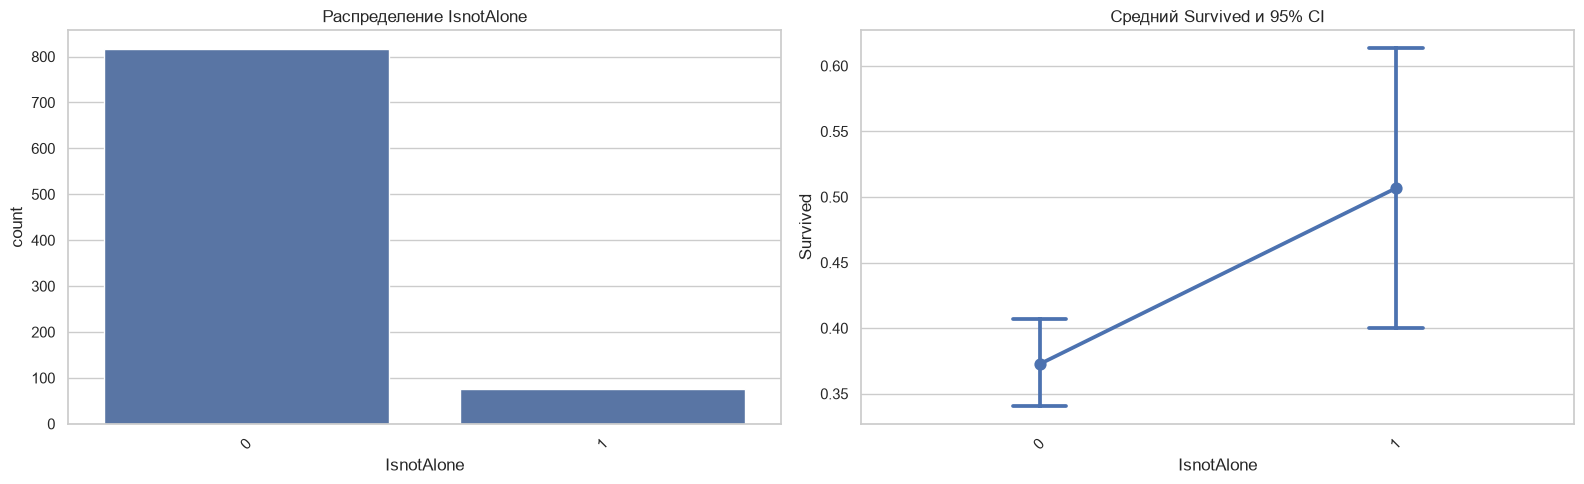

In [47]:
LAST_FIGURE = None
DISCRETE_FEATURE = "IsnotAlone"

if DISCRETE_FEATURE is None:
    print(
        "В FEATURE_GROUPS нет count-признаков. "
        "Добавьте дискретные счётные признаки в группу count."
    )
else:
    plot_frame = fare_frame[[DISCRETE_FEATURE, TARGET]].copy()
    plot_frame[DISCRETE_FEATURE] = (
        plot_frame[DISCRETE_FEATURE]
        .astype("object")
        .where(plot_frame[DISCRETE_FEATURE].notna(), "<NA>")
    )

    observed_levels = sorted(
        fare_frame[DISCRETE_FEATURE].dropna().unique().tolist()
    )
    if fare_frame[DISCRETE_FEATURE].isna().any():
        observed_levels.append("<NA>")

    if pd.api.types.is_numeric_dtype(fare_frame[TARGET]):
        discrete_target_report = grouped_target_report(
            fare_frame,
            feature=DISCRETE_FEATURE,
            target=TARGET,
            ci_level=CI_LEVEL,
            n_boot=CI_BOOTSTRAPS,
            seed=CI_SEED,
        )
        discrete_target_report.insert(
            1,
            "share",
            discrete_target_report["rows"] / len(fare_frame),
        )
        estimate_column = (
            "target_rate"
            if "target_rate" in discrete_target_report.columns
            else "target_mean"
        )
        report_formats = {
            "share": "{:.2%}",
            "ci_low": "{:.2%}" if estimate_column == "target_rate" else "{:.3f}",
            "ci_high": "{:.2%}" if estimate_column == "target_rate" else "{:.3f}",
            estimate_column: "{:.2%}" if estimate_column == "target_rate" else "{:.3f}",
        }
        display(discrete_target_report.style.format(report_formats))
    else:
        discrete_value_report = (
            plot_frame[DISCRETE_FEATURE]
            .value_counts(dropna=False, sort=False)
            .rename("rows")
            .to_frame()
        )
        discrete_value_report["share"] = (
            discrete_value_report["rows"] / len(fare_frame)
        )
        display(discrete_value_report.style.format({"share": "{:.2%}"}))
        display(
            pd.crosstab(
                plot_frame[DISCRETE_FEATURE],
                plot_frame[TARGET],
                normalize="index",
                dropna=False,
            ).style.format("{:.2%}")
        )

    plot_levels = observed_levels
    if len(plot_levels) > MAX_DISCRETE_LEVELS:
        frequent_levels = (
            plot_frame[DISCRETE_FEATURE]
            .value_counts()
            .head(MAX_DISCRETE_LEVELS)
            .index.tolist()
        )
        frequent_set = set(frequent_levels)
        plot_levels = [
            level for level in observed_levels if level in frequent_set
        ]
        plot_frame = plot_frame[
            plot_frame[DISCRETE_FEATURE].isin(frequent_set)
        ]
        print(
            f"На графике показаны {MAX_DISCRETE_LEVELS} наиболее частых "
            f"уровней из {len(observed_levels)}. Таблица содержит все уровни."
        )

    figure, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.countplot(
        data=plot_frame,
        x=DISCRETE_FEATURE,
        order=plot_levels,
        ax=axes[0],
    )
    axes[0].set_title(f"Распределение {DISCRETE_FEATURE}")
    axes[0].tick_params(axis="x", rotation=45)

    if pd.api.types.is_numeric_dtype(fare_frame[TARGET]):
        sns.pointplot(
            data=plot_frame,
            x=DISCRETE_FEATURE,
            y=TARGET,
            order=plot_levels,
            estimator="mean",
            errorbar=("ci", CI_LEVEL),
            n_boot=CI_BOOTSTRAPS,
            seed=CI_SEED,
            capsize=0.15,
            ax=axes[1],
        )
        axes[1].set_title(
            f"Средний {TARGET} и {CI_LEVEL}% CI"
        )
    else:
        sns.countplot(
            data=plot_frame,
            x=DISCRETE_FEATURE,
            hue=TARGET,
            order=plot_levels,
            ax=axes[1],
        )
        axes[1].set_title(
            f"Распределение {TARGET} по {DISCRETE_FEATURE}"
        )
    axes[1].tick_params(axis="x", rotation=45)

    figure.tight_layout()
    LAST_FIGURE = figure
    plt.show()

### Вывод по дискретному признаку

- **Какой признак исследовался:**
- **Какие значения доминируют:**
- **Есть ли редкие уровни и достаточно ли в них строк:**
- **Как меняется target между значениями:**
- **Насколько широки CI и устойчив ли эффект:**
- **Связь монотонная, пороговая или нелинейная:**
- **Нужно ли объединение редких значений, binning или преобразование:**
- **Возможная feature-гипотеза:**
- **Следующий шаг:**

## 4. Первичный обзор текстового признака

Этот раздел выполняет только минимальную диагностику, после которой определяется дальнейший путь признака. Он не запускает NLP-анализ автоматически.

По умолчанию выбирается первый признак из группы `text`. При необходимости явно замените `TEXT_FEATURE`.

Проверки:

1. первые и случайные 20 строк;
2. `NaN`, пустые строки и строки со специальными символами;
3. уникальность и точные повторения, включая top-20 значений.

`NaN` не является текстом — это отдельное состояние отсутствующего значения, которое необходимо исследовать вместе с текстовым полем.

In [8]:
# TEXT_FEATURE = text_features[0] if text_features else None
TEXT_FEATURE = "Ticket"
if TEXT_FEATURE is None:
    print(
        "В FEATURE_GROUPS нет text-признаков. "
        "Добавьте текстовые поля в группу text."
    )
else:
    context_columns = list(
        dict.fromkeys(
            column
            for column in (KEY, TEXT_FEATURE, TARGET)
            if column is not None and column in fare_frame.columns
        )
    )
    text_series = fare_frame[TEXT_FEATURE].astype("string")
    rows = len(fare_frame)
    sample_size = min(TEXT_SAMPLE_SIZE, rows)

    print("Первые строки:")
    display(fare_frame[context_columns].head(TEXT_SAMPLE_SIZE))

    print("Случайные строки:")
    if sample_size:
        display(
            fare_frame[context_columns].sample(
                n=sample_size,
                random_state=TEXT_SAMPLE_SEED,
            )
        )
    else:
        print("Датасет пуст.")

    missing_mask = text_series.isna()
    empty_mask = text_series.notna() & text_series.str.strip().eq("")
    special_mask = (
        text_series.fillna("")
        .str.contains(TEXT_SPECIAL_PATTERN, regex=True)
    )

    text_quality_report = pd.DataFrame(
        [
            {
                "rows": rows,
                "missing": int(missing_mask.sum()),
                "missing_share": float(missing_mask.mean()) if rows else 0.0,
                "empty_or_whitespace": int(empty_mask.sum()),
                "empty_share": float(empty_mask.mean()) if rows else 0.0,
                "rows_with_special_chars": int(special_mask.sum()),
                "special_chars_share": (
                    float(special_mask.mean()) if rows else 0.0
                ),
            }
        ]
    )
    text_quality_display = text_quality_report.copy()
    for column in (
        "missing_share",
        "empty_share",
        "special_chars_share",
    ):
        text_quality_display[column] = text_quality_display[column].map(
            lambda value: f"{value:.2%}"
        )
    display(text_quality_display)

    print("Строки с NaN:")
    if missing_mask.any():
        display(fare_frame.loc[missing_mask, context_columns].head(TEXT_SAMPLE_SIZE))
    else:
        print("NaN не обнаружены.")

    print("Пустые строки или строки только из пробелов:")
    if empty_mask.any():
        display(fare_frame.loc[empty_mask, context_columns].head(TEXT_SAMPLE_SIZE))
    else:
        print("Пустые строки не обнаружены.")

    print("Примеры строк со специальными символами:")
    if special_mask.any():
        display(fare_frame.loc[special_mask, context_columns].head(TEXT_SAMPLE_SIZE))
        special_character_report = (
            text_series[special_mask]
            .str.findall(TEXT_SPECIAL_PATTERN)
            .explode()
            .value_counts()
            .rename_axis("character")
            .reset_index(name="count")
            .head(TEXT_TOP_VALUES)
        )
        display(special_character_report)
    else:
        print("Специальные символы не обнаружены.")

    non_missing_text = text_series.dropna()
    value_counts = non_missing_text.value_counts(dropna=False)
    unique_values = int(non_missing_text.nunique(dropna=True))
    duplicate_rows = int(non_missing_text.duplicated(keep=False).sum())
    repeated_excess = int(non_missing_text.duplicated().sum())
    top_values = value_counts.head(TEXT_TOP_VALUES)
    top_values_share = (
        float(top_values.sum() / rows) if rows else 0.0
    )

    text_repetition_report = pd.DataFrame(
        [
            {
                "rows": rows,
                "non_missing": int(non_missing_text.size),
                "unique_values": unique_values,
                "unique_share_of_non_missing": (
                    unique_values / non_missing_text.size
                    if non_missing_text.size
                    else 0.0
                ),
                "rows_belonging_to_repeated_values": duplicate_rows,
                "repeated_excess_rows": repeated_excess,
                f"top_{TEXT_TOP_VALUES}_coverage": top_values_share,
            }
        ]
    )
    coverage_column = f"top_{TEXT_TOP_VALUES}_coverage"
    text_repetition_display = text_repetition_report.copy()
    for column in (
        "unique_share_of_non_missing",
        coverage_column,
    ):
        text_repetition_display[column] = text_repetition_display[column].map(
            lambda value: f"{value:.2%}"
        )
    display(text_repetition_display)

    top_values_report = top_values.rename("rows").reset_index()
    top_values_report.columns = [TEXT_FEATURE, "rows"]
    top_values_report["share"] = top_values_report["rows"] / rows
    top_values_report["cumulative_share"] = (
        top_values_report["share"].cumsum()
    )
    top_values_report[TEXT_FEATURE] = top_values_report[TEXT_FEATURE].map(
        lambda value: (
            value
            if len(str(value)) <= TEXT_PREVIEW_CHARS
            else str(value)[: TEXT_PREVIEW_CHARS - 1] + "…"
        )
    )
    print(f"Top-{TEXT_TOP_VALUES} точных значений:")
    top_values_display = top_values_report.copy()
    for column in ("share", "cumulative_share"):
        top_values_display[column] = top_values_display[column].map(
            lambda value: f"{value:.2%}"
        )
    display(top_values_display)

Первые строки:


,PassengerId,Ticket,Survived
0,1,A/5 21171,0
1,2,PC 17599,1
2,3,STON/O2. 3101282,1
3,4,113803,1
4,5,373450,0
5,6,330877,0
6,7,17463,0
7,8,349909,0
8,9,347742,1
9,10,237736,1


Случайные строки:


,PassengerId,Ticket,Survived
709,710,2661,1
439,440,C.A. 18723,0
840,841,SOTON/O2 3101287,0
720,721,248727,1
39,40,2651,1
290,291,19877,1
300,301,9234,1
333,334,345764,0
208,209,367231,1
136,137,11752,1


,rows,missing,missing_share,empty_or_whitespace,empty_share,rows_with_special_chars,special_chars_share
0,891,0,0.00%,0,0.00%,150,16.84%


...

,PassengerId,Ticket,Survived
0,1,A/5 21171,0
2,3,STON/O2. 3101282,1
12,13,A/5. 2151,0
33,34,C.A. 24579,0
37,38,A./5. 2152,0
43,44,SC/Paris 2123,1
45,46,S.C./A.4. 23567,0
51,52,A/4. 39886,0
56,57,C.A. 31026,1
58,59,C.A. 34651,1


,character,count
0,.,197
1,/,98


,rows,non_missing,unique_values,unique_share_of_non_missing,rows_belonging_to_repeated_values,repeated_excess_rows,top_20_coverage
0,891,891,681,76.43%,344,210,10.77%


Top-20 точных значений:


,Ticket,rows,share,cumulative_share
0,347082,7,0.79%,0.79%
1,1601,7,0.79%,1.57%
2,CA. 2343,7,0.79%,2.36%
3,3101295,6,0.67%,3.03%
4,CA 2144,6,0.67%,3.70%
5,347088,6,0.67%,4.38%
6,382652,5,0.56%,4.94%
7,S.O.C. 14879,5,0.56%,5.50%
8,349909,4,0.45%,5.95%
9,347077,4,0.45%,6.40%


In [16]:
# mask =  train["Ticket"].str.contains("A", regex=False, na=False)
mask = train["Ticket"].duplicated()
# Добавляем .head(10) для вывода первых 10 строк
display(train.loc[mask, ["Parch","SibSp", "Ticket","Fare", "Name", "Pclass", "Survived", "Sex","Cabin"]].sort_values(by="Ticket").head(50))




,Parch,SibSp,Ticket,Fare,Name,Pclass,Survived,Sex,Cabin
504,0,0,110152,86.5000,"Maioni, Miss. Roberta",1,1,female,B79
759,0,0,110152,86.5000,"Rothes, the Countess. of (Lucy Noel Martha Dye...",1,1,female,B77
558,1,1,110413,79.6500,"Taussig, Mrs. Emil (Tillie Mandelbaum)",1,1,female,E67
585,2,0,110413,79.6500,"Taussig, Miss. Ruth",1,1,female,E68
475,0,0,110465,52.0000,"Clifford, Mr. George Quincy",1,0,male,A14
523,1,0,111361,57.9792,"Hippach, Mrs. Louis Albert (Ida Sophia Fischer)",1,1,female,B18
356,1,0,113505,55.0000,"Bowerman, Miss. Elsie Edith",1,1,female,E33
829,0,0,113572,80.0000,"Stone, Mrs. George Nelson (Martha Evelyn)",1,1,female,B28
802,2,1,113760,120.0000,"Carter, Master. William Thornton II",1,1,male,B96 B98
763,2,1,113760,120.0000,"Carter, Mrs. William Ernest (Lucile Polk)",1,1,female,B96 B98


In [95]:
mask_two_dots = train["Name"].str.count(r"\.") == 2

# Выводим результат
display(train.loc[mask_two_dots, ["PassengerId", "Name"]])

,PassengerId,Name
513,514,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)"


### Предварительный вывод по текстовому признаку

- **Какой признак исследовался:**
- **Что показали первые и случайные строки:**
- **Есть ли NaN, пустые строки или необычные специальные символы:**
- **Насколько часто повторяются полные значения:**
- **Какую долю покрывают top-20 значений:**
- **Предварительный тип:** категория / идентификатор / структурированная строка / свободный текст / пока непонятно
- **Почему:**
- **Нужен ли дополнительный анализ:**
- **Следующий шаг:**

## 5. Корреляции

Сравните `spearman` и `pearson`. Корреляционная матрица используется как диагностика, а не как автоматический способ отбора признаков.

,Age,Fare,SibSp,Parch,Pclass,Survived
Age,1.000000,0.135051,-0.182061,-0.254212,-0.361666,-0.052565
Fare,0.135051,1.000000,0.447113,0.410074,-0.688032,0.323736
SibSp,-0.182061,0.447113,1.000000,0.450014,-0.043019,0.088879
Parch,-0.254212,0.410074,0.450014,1.000000,-0.022801,0.138266
Pclass,-0.361666,-0.688032,-0.043019,-0.022801,1.000000,-0.339668
Survived,-0.052565,0.323736,0.088879,0.138266,-0.339668,1.000000


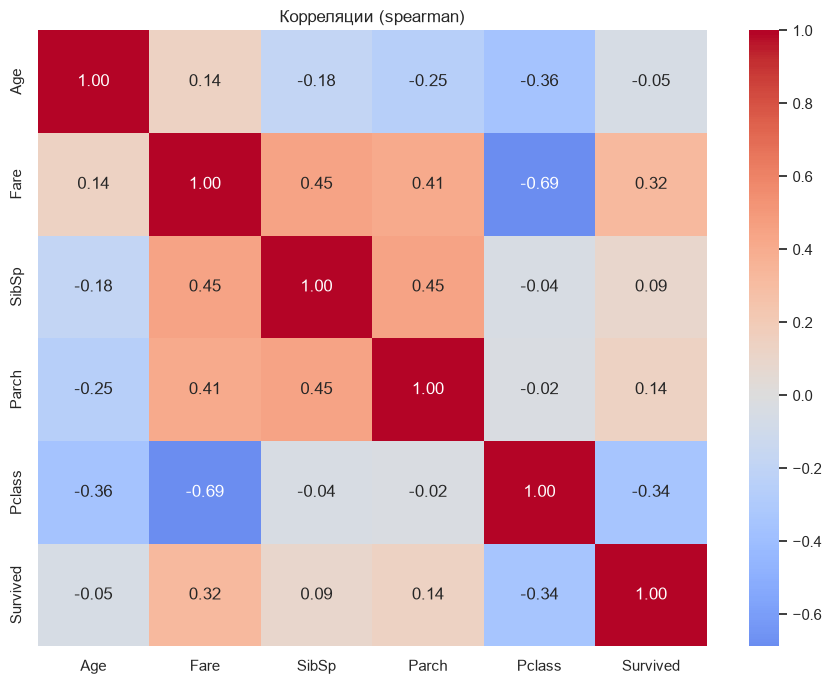

In [94]:
LAST_FIGURE = None
CORRELATION_METHOD = "spearman"  # замените на "pearson" для линейной связи
correlation_columns = list(dict.fromkeys([*numeric_features,"Pclass", TARGET]))

if len(correlation_columns) < 2:
    print("Недостаточно числовых признаков для корреляционного анализа.")
else:
    correlation_report = train[correlation_columns].corr(
        method=CORRELATION_METHOD
    )
    display(correlation_report)

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        correlation_report,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
    )
    plt.title(f"Корреляции ({CORRELATION_METHOD})")
    plt.tight_layout()
    LAST_FIGURE = plt.gcf()
    plt.show()

### Вывод по корреляциям

- **Сильные связи с target:**
- **Сильные связи между признаками:**
- **Возможное дублирование / multicollinearity:**
- **Нелинейные связи, которые корреляция могла не увидеть:**
- **Следующий шаг:**

## 6. Линейная связь двух числовых признаков

Выберите `X_FEATURE` и `Y_FEATURE`. Цветом отмечается target, а линия показывает общий линейный тренд.

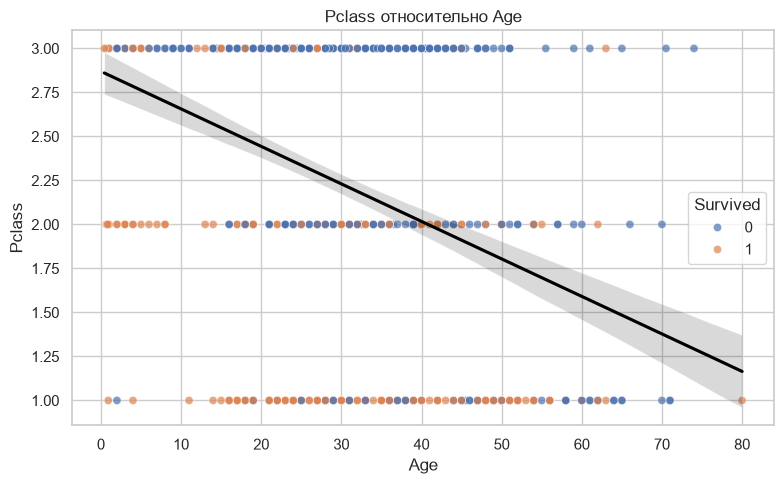

In [87]:
LAST_FIGURE = None
X_FEATURE = "Age" if numeric_features else None
Y_FEATURE = "Pclass" if len(numeric_features) > 1 else None

if X_FEATURE is None or Y_FEATURE is None:
    print("Нужно минимум два numeric/count признака.")
else:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=train,
        x=X_FEATURE,
        y=Y_FEATURE,
        hue=TARGET,
        alpha=0.7,
    )
    sns.regplot(
        data=train,
        x=X_FEATURE,
        y=Y_FEATURE,
        scatter=False,
        ci=CI_LEVEL,
        n_boot=CI_BOOTSTRAPS,
        seed=CI_SEED,
        color="black",
    )
    plt.title(f"{Y_FEATURE} относительно {X_FEATURE}")
    plt.tight_layout()
    LAST_FIGURE = plt.gcf()
    plt.show()

### Вывод по линейной связи

- **Какая пара исследовалась:**
- **Видна ли линейная или монотонная связь:**
- **Различаются ли классы target:**
- **Есть ли кластеры или выбросы:**
- **Следующий шаг:**

## 7. Взаимодействие двух категориальных признаков

Для Titanic шаблон выберет `Sex × Pclass`, если оба признака настроены. Проверяйте также количество объектов в каждой комбинации.

Relatives,0,1,2,3,4,5,6,7,10
Embarked,,,,,,,,,
C,43.53%,66.67%,60.87%,85.71%,100.00%,nan%,nan%,nan%,nan%
Q,40.35%,55.56%,33.33%,nan%,nan%,0.00%,nan%,nan%,nan%
S,25.70%,49.50%,58.90%,68.18%,7.69%,17.65%,33.33%,0.00%,0.00%


Relatives,0,1,2,3,4,5,6,7,10
Embarked,,,,,,,,,
C,85,51,23,7,2,0,0,0,0
Q,57,9,6,0,0,5,0,0,0
S,393,101,73,22,13,17,12,6,7
NaN,2,0,0,0,0,0,0,0,0


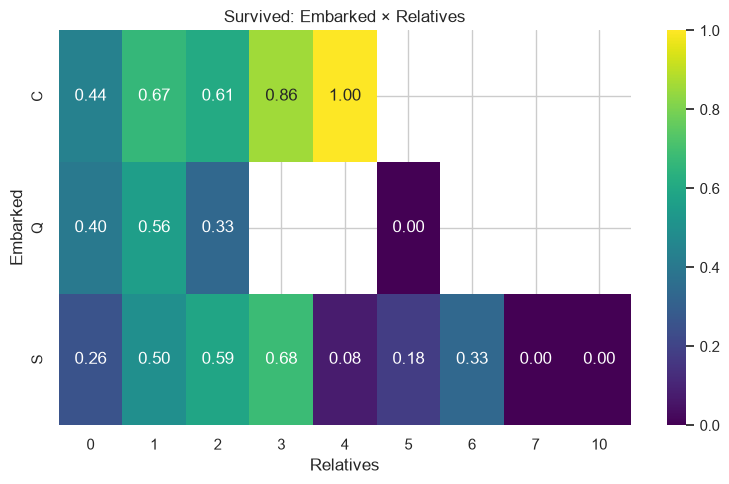

In [84]:
LAST_FIGURE = None
FIRST_FEATURE = (
    "Embarked"
    
)
SECOND_FEATURE = (
    "Relatives"
    if "Pclass" in categorical_features
    else (categorical_features[1] if len(categorical_features) > 1 else None)
)

if FIRST_FEATURE is None or SECOND_FEATURE is None:
    print("Нужно минимум два categorical/ordinal признака.")
else:
    interaction_rate = pd.pivot_table(
        train,
        values=TARGET,
        index=FIRST_FEATURE,
        columns=SECOND_FEATURE,
        aggfunc="mean",
    )
    interaction_count = pd.crosstab(
        train[FIRST_FEATURE],
        train[SECOND_FEATURE],
        dropna=False,
    )
    display(interaction_rate.style.format("{:.2%}"))
    display(interaction_count)

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        interaction_rate,
        annot=True,
        fmt=".2f",
        cmap="viridis",
    )
    plt.title(f"{TARGET}: {FIRST_FEATURE} × {SECOND_FEATURE}")
    plt.tight_layout()
    LAST_FIGURE = plt.gcf()
    plt.show()

### Вывод по взаимодействию

- **Какая пара исследовалась:**
- **Меняется ли эффект первого признака внутри второго:**
- **Достаточно ли наблюдений в комбинациях:**
- **Возможная interaction-feature:**
- **Следующий шаг:**

## 8. Сохранить важный результат в Obsidian

Карточка наблюдения может содержать:

1. только график;
2. только одну или несколько таблиц;
3. график и таблицы вместе.

После заполнения полей установите `SAVE_FINDING = True`. Будут созданы карточка `eda/findings/EDA-NNN.md`, необходимые артефакты в `assets/eda/` и ссылка в [[docs/02_eda.md#Сохранённые EDA-наблюдения]].

### Как передать таблицу

Передавайте исходный `pandas.DataFrame`, а не объект `.style`:

```python
TABLES_TO_SAVE = {
    "Название таблицы": dataframe_variable,
}
```

Форматирование отдельных столбцов задаётся отдельно:

```python
TABLE_FORMATS = {
    "Название таблицы": {
        "target_rate": "{:.2%}",
        "ci_low": "{:.2%}",
        "ci_high": "{:.2%}",
    },
}
```

Таблица до `TABLE_PREVIEW_ROWS` строк полностью встраивается в Markdown-карточку. Для более крупной таблицы в карточке показывается preview, а полный результат сохраняется как CSV.

Чтобы сохранить только таблицу, установите `FIGURE_TO_SAVE = None`. Каждый запуск с `SAVE_FINDING = True` создаёт новую карточку и ничего не перезаписывает.

In [49]:
SAVE_FINDING = True  # измените на True только после заполнения полей
# Что сохранить. Для table-only установите FIGURE_TO_SAVE = None.
FIGURE_TO_SAVE = LAST_FIGURE
TABLES_TO_SAVE = {"Люди без родственников путешествующие в группе": fare_frame[[DISCRETE_FEATURE, TARGET]]
    # "Название таблицы": dataframe_variable,
}
TABLE_FORMATS = {
    # "Название таблицы": {
    #     "target_rate": "{:.2%}",
    #     "ci_low": "{:.2%}",
    #     "ci_high": "{:.2%}",
    # },
}
TABLE_PREVIEW_ROWS = 30

if SAVE_FINDING:
    if FIGURE_TO_SAVE is None and not TABLES_TO_SAVE:
        raise ValueError("Добавьте график, таблицу или оба артефакта.")

    saved_finding = save_eda_finding(
        project_root=PROJECT_ROOT,
        title="анализ новой фичи IsnotAlone",
        question="Влияет ли не только родство но и наличие знакомых людей на выживаемость?",
        method="вывел людей у которых TicketgroupSize>1, но при этом 1 FamilySize",
        conclusion="Путешествие со знакомыми людьми увеличивает выживаемость примерно на 15% выше.",
        figure=FIGURE_TO_SAVE,
        tables=TABLES_TO_SAVE,
        table_formats=TABLE_FORMATS,
        table_preview_rows=TABLE_PREVIEW_ROWS,
        features=["IsnotAlone"],  # например: [CATEGORICAL_FEATURE]
        hypothesis="необходимо выделить отдельный признак путешествия в группе",
    )
    print("Сохранено:", saved_finding.note_wikilink)
else:
    print("Заполните поля и установите SAVE_FINDING = True.")

Сохранено: [[eda/findings/EDA-019.md|EDA-019 — анализ новой фичи IsnotAlone]]


## Итог исследования

| Вопрос | Наблюдение | Надёжность | Решение | Ссылка на гипотезу |
|---|---|---|---|---|
|  |  |  |  |  |

### Кандидаты в признаки

| Feature | Источники | Тип | Почему может помочь | Как проверить |
|---|---|---|---|---|
|  |  |  |  |  |

### Завершение

- [ ] Каждый важный график имеет текстовый вывод.
- [ ] Проверен размер групп и устойчивость наблюдений.
- [ ] Корреляция не интерпретируется как причинность.
- [ ] Leakage-кандидаты отмечены отдельно.
- [ ] Значимые идеи оформлены в [[hypotheses/_index.md]].
- [ ] Главные выводы перенесены в [[docs/02_eda.md]].
- [ ] Принятые engineered features будут реализованы в `src/ml_project/features.py`, а не только в notebook.